---

<h1><center>ENGIN178 Final Project<br><br> Group 14 </center></h1>

---
This project is designed to take blended body delta wing aircraft positional state given in yaw angle, pitch angle, as well as the absolute and relative degree of elevon and map that to aerodynamic force and moment coefficients to be used in a controller.

0. Load the data from the master sheet
1. Scramble the ordered data from the mastersheet into a new shuffled csv file
2. Split the data into training, validation, and testing datasets
3. Normalize the data using Scikit-Learn 'Standard-Scaler()' method
4. Organize and fit our data into input sequences and output values
5. Train and test the following models
    + 5.1 Multi-Linear Regression 
    + 5.2 Random-Forest Regressor 
    + 5.3 SimpleRNN Neural-Network 
    + 5.4 MLP Neural-Network 

6. Compare the models
7. Compute performance of the best model

In [9]:
#importing dependencies (Copied from HW4)
import os
import random
import numpy as np
import pandas as pd
from pandas.core.indexes.datetimes import DatetimeIndex
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
#from resources.hashutils import *
os.environ['PYTHONHASHSEED'] = '0'  # optional, for hash-based functions
#random.seed(2434)
#np.random.seed(2434)
#torch.manual_seed(2434)
#torch.use_deterministic_algorithms(True)
np.set_printoptions(precision=4)

def predict_model(model, x):
    model.eval()
    x_tensor = torch.tensor(np.asarray(x), dtype=torch.float32)
    with torch.no_grad():
        yhat = model(x_tensor).detach().cpu().numpy()
    return yhat

def predict_any(model, x):
    if isinstance(model, nn.Module):
        return predict_model(model, x)
    return model.predict(x)


## 0.  Importing the aero parameter 'Master Sheet'

Straightforward import of the ordered master sheet into our notebook using a Pandas data frame, we also remove a vestigal column describing the data source

In [10]:
# loads the data and removes the 'source_file' output column
rawDat = pd.read_csv('aero_master.csv').drop('source_file', axis=1)


## 1. Shuffle the aero parameter 'Master Sheet'

The raw data from the master sheet is organized in the angle of attack sweeps due to how data formatting is done in VSPAero. This means that if we were to split this csv using the sequential sorting of training, validation, and test data we would be missing entire sweeps for the training data. 

+ To remedy this the rows of the csv need to be randomly shuffled to ensure an even distribution of the different cfd sweeps. Using pandas [`df.sample()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.sample.html) method using a specific random state (to ensure consistency).

In [11]:
shuffledDat = rawDat.sample(frac=1, random_state = 31).reset_index(drop=True).to_csv('shuffledAeroMaster.csv', index=False)

In [12]:
# if the shuffle has alreday been done just run this 
shuffledDat = pd.read_csv('shuffledAeroMaster.csv')

## 2. Splitting the shuffled data

We want to split up our shuffled data into respective train, validate, and test data sets. A good way to do this is by defining our ratios that we want to split the data, then sequentially slicing off the specified ratios into their respective sets.

**This is crucially done before normalizing the data to prevent data leakage in our training.**

+ In this specific case we chose a 70% train, 10% validate, and 20% test ratio.



In [ ]:
# create the function that will split our data up into train, validate, and test lists. pt indicates percent train, pv 
# indicates percent validate... please use float not percent!!!

def splitData(pt,pv):

    assert(pt>=0)
    assert(pv>=0)
    assert(pt+pv<=1)

    N = shuffledDat.shape[0]

    trainEnd = int(N*pt)
    valEnd = trainEnd + int(N*pv)

    dataTrain = shuffledDat.copy().iloc[:trainEnd]
    dataValidate = shuffledDat.copy().iloc[trainEnd:valEnd]
    dataTest = shuffledDat.copy().iloc[valEnd:]

    
    return dataTrain, dataValidate, dataTest

In [14]:
# run the function to actually split the data
dataTrain, dataValidate, dataTest = splitData(0.70,0.10)

## 3. Normalizing each dataset

This dataset doesn't have a large feature range, but it is still required that we normalize the data to insure there is no feature domination during our training. We can do this very easily using [`StandardScaler()`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html) and normalize our inputs and outputs.

In [15]:
# normalize and scale the data using StandardScaler() method from scikit learn
from sklearn.preprocessing import StandardScaler

xScaler = StandardScaler()
yScaler = StandardScaler()

## 4. Organizing and fitting out inputs and outputs 

We need to define what our inputs and outputs are:
+ X = Attitude $\alpha$ & $\beta$, combined elevon pitch, and elevon $\Delta$. 
+ Y = $C_L, C_d, C_y, C_l, C_m, C_n$

Once this is done we must scale all of our data according to the scaled variables we defined in the previous section (`xScaled` & `yScaled`). 
+ We use [`fit_transform()`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html#sklearn.preprocessing.StandardScaler.fit_transform) on our training data to calculate its stats then apply the scale, for all other data we simply use [`transform()`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html#sklearn.preprocessing.StandardScaler.transform) to prevent data leakage.

In [ ]:
# creates our input/output training set
xTrain = dataTrain[["alpha_deg","beta_deg","deltaS_deg","deltaD_deg"]]
yTrain = dataTrain[["CL","CD","CY","Cl","Cm","Cn"]]

# creates our input/output validate set
xValidate = dataValidate[["alpha_deg","beta_deg","deltaS_deg","deltaD_deg"]]
yValidate = dataValidate[["CL","CD","CY","Cl","Cm","Cn"]]

# creates our input/output test set
xTest = dataTest[["alpha_deg","beta_deg","deltaS_deg","deltaD_deg"]]
yTest = dataTest[["CL","CD","CY","Cl","Cm","Cn"]]

# scales all of our inputs
xTrainScaled = xScaler.fit_transform(xTrain)
xTestScaled = xScaler.transform(xTest)
xValidateScaled = xScaler.transform(xValidate)

# scales all of our outputs
yTrainScaled = yScaler.fit_transform(yTrain)
yTestScaled = yScaler.transform(yTest)
yValidateScaled = yScaler.transform(yValidate)

## 5.1 Building multi-linear regression

This will be our simplest model to act as a baseline to compare all of our other models to. We know that some of our parameters should exhibit a **linear relationship** with attitude, specifically:
+ $C_L$ (Coefficient of Lift)
+ $C_m$ (Coefficient of Moment)

These parameters should yield a **very strong** linear model. In future training sessions we can compare the relative performance for our linear parameters. 

However not all of these parameters are known to show a linear relationship with attitude, specifically:
+ $C_l$ 
+ $C_n$ (Coefficient of yaw/normal)
+ $C_Y$ (Coefficient of aerodynamic side-force)
+ $C_d$ (Coefficient of drag)

### 5.1.1 Initlizing and traning the linear regression model

Creating and training a LR model using Scikit-Learn is very simple, we simply create the LR model then train it on scaled data. We can then use the model with the validation set to evaluate its Mean Absolute Error.

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

# create our sklearn regression model
modelLr = LinearRegression()

# train the model, it gets scaled inputs and will learn to map them to the unscaled targets
modelLr.fit(xTrainScaled, yTrain)

# predict with the validation set
validatePred = modelLr.predict(xValidateScaled)

# model evaluation using MAE 
individualMaes = mean_absolute_error(yValidate, validatePred, multioutput='raw_values')

parameters = ["CL", "CD", "CY", "Cl", "Cm", "Cn"]
print("Multi-Linear Regression Validation MAE by Parameter:")
for param, mae in zip(parameters, individualMaes):
    print(f"{param}: {mae:.5f}")

Multi-Linear Regression Validation MAE by Parameter:
CL: 0.00426
CD: 0.01749
CY: 0.00147
Cl: 0.00410
Cm: 0.00785
Cn: 0.00119


### 5.1.2 Evaluating and plotting the multi-linear regression

With our model trained we can now evaluate its performance and plot its performance vs the actual data. In the previous section we calculated each parameters MAE, this metric is not entirely helpful as it doesn't account for the scale and variance of each specific output. 

To remedy this we employ an $R^2$ score and NMAE to evaluate the model accuracy, and get an idea of by how far off our predicted values are.

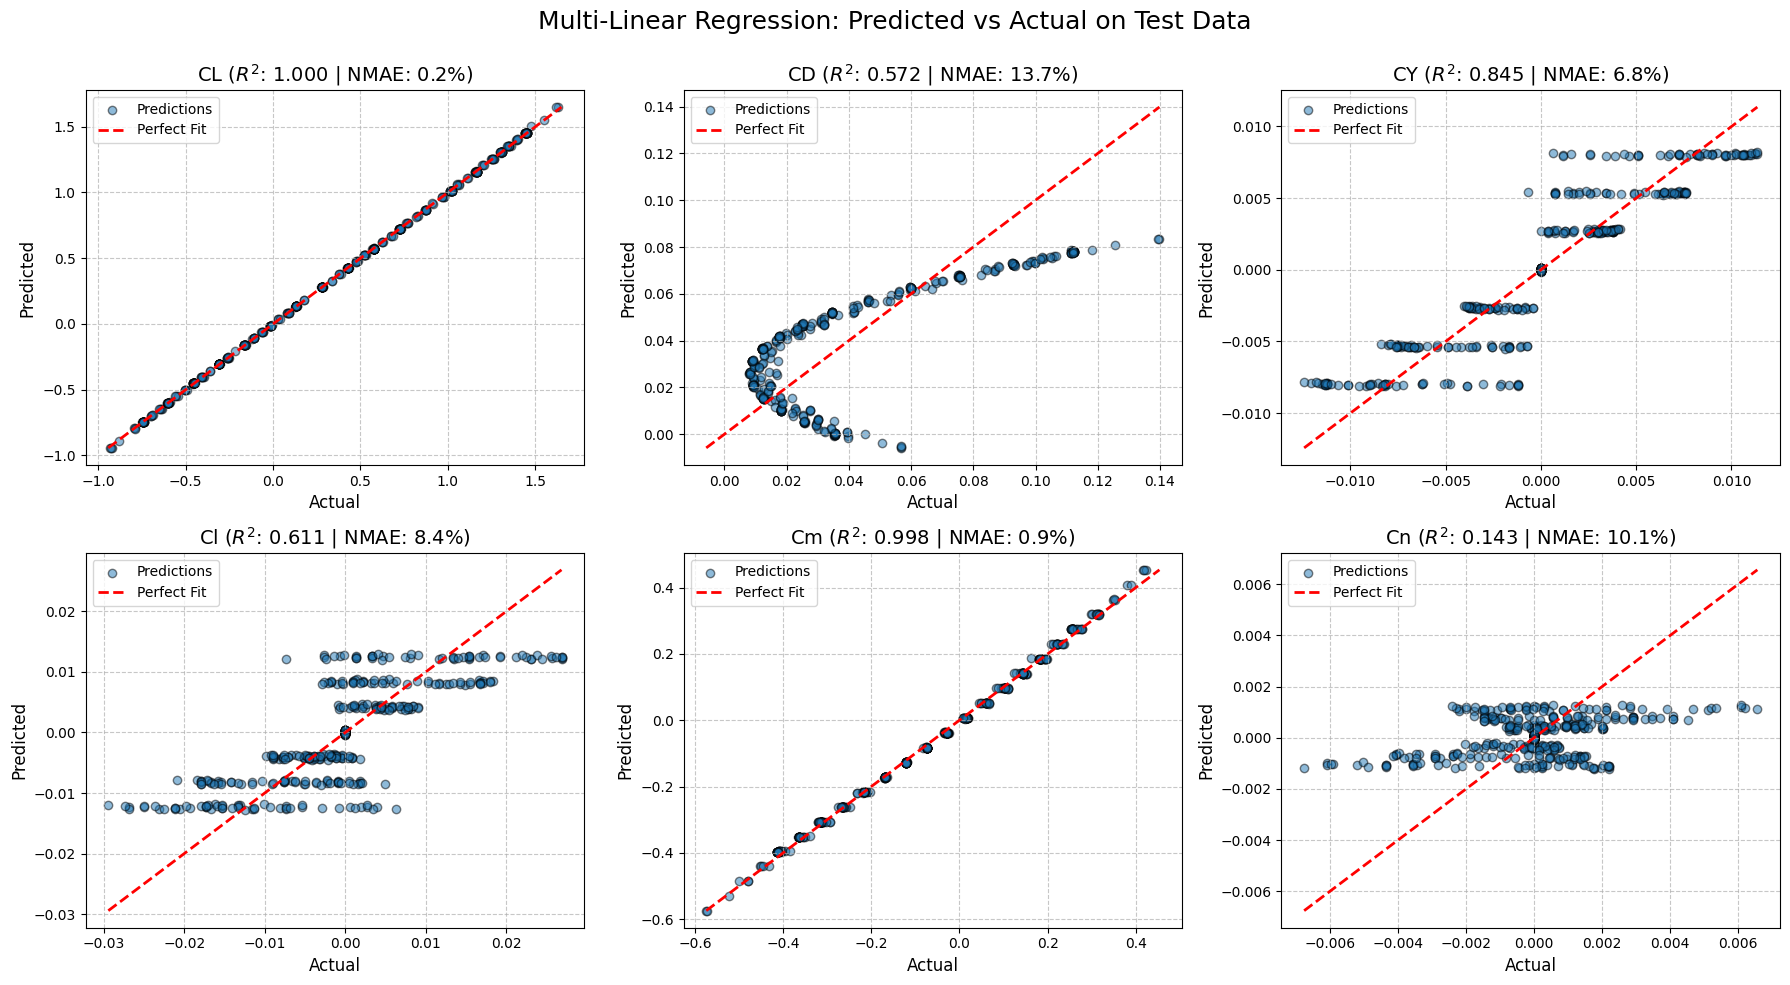

In [ ]:
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# extracts the test features then scales adequately 
xTest = dataTest[["alpha_deg", "beta_deg", "deltaS_deg", "deltaD_deg"]]
yTest = dataTest[["CL", "CD", "CY", "Cl", "Cm", "Cn"]]

xTestScaled = xScaler.transform(xTest)

# predict using the trained model
testPred = modelLr.predict(xTestScaled)

# calculate standard MAE and R^2 for all parameters
testMaes = mean_absolute_error(yTest, testPred, multioutput='raw_values')
testR2 = r2_score(yTest, testPred, multioutput='raw_values')

parameters = ["CL", "CD", "CY", "Cl", "Cm", "Cn"]

# plot generation
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Multi-Linear Regression: Predicted vs Actual on Test Data', fontsize=18)

axes = axes.flatten()

for i, target in enumerate(parameters):
    ax = axes[i]
    actual = yTest[target].values
    predicted = testPred[:, i]
    
    # calculate NMAE (normalized by the range of actual values)
    range_val = actual.max() - actual.min()
    nmae = (testMaes[i] / range_val) * 100 if range_val != 0 else 0
    
    # scatter plots
    ax.scatter(actual, predicted, alpha=0.5, edgecolor='k', label='Predictions')
    
    # creates and "ideal" line
    min_val = min(actual.min(), predicted.min())
    max_val = max(actual.max(), predicted.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Fit')
    
    # titles and stuff
    ax.set_title(f"{target} ($R^2$: {testR2[i]:.3f} | NMAE: {nmae:.1f}%)", fontsize=14)
    ax.set_xlabel('Actual', fontsize=12)
    ax.set_ylabel('Predicted', fontsize=12)
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.show()

As the plot above shows, some of the parameters are much better suited towards linear regression than others.

+ $C_L$ & $C_m$ both exhibit a **perfectly linear** fit with very low NMAE scores, we can use this performance to gauge future model performance.
+ All of the other models however show some significant deviation from the perfect fit, in the $C_D$ plot we can see the parabolic relationship between attitude and drag (drag polar) very clearly on this graph. The other parameters have some odd relationships that do not fit to a linear regression very well.

With this in mind, we can move on to different machine learning models to better predict these non linear relationships.

## 5.2 Building a SimpleRNN neural network

Now that we have tested two regression models we will employ a neural-network in an attempt to accurately model our parameters. A neural network is particularly useful for analyzing complex non-linear patterns (which our regression models have shown to exist in our data). 

We have a modest dataset of roughly 2000 vector data points which is just enough to make a neural network worth while. First we are going to employ a SimpleRNN which specializes in data that is sequential, this isn't particularly tailored towards the data but it can still yield results.

### 5.2.1 Data preparation 

PyTorch requires all of our data sets to be reshaped and converted into torch tensors. We will also create a data loader that packs our tensor dataset into batch sizes of 32.

In [ ]:
#data preparation: this code block converts our data pools into respective pytorch tensors
#specifically for this RNN we have to reshape our inputs to fit with the RNN architecture

# reshaping from (N, 4) to (N, 1, 4)
xTrainSeq = torch.tensor(xTrainScaled, dtype=torch.float32).reshape(-1, 1, 4)
xValidateSeq = torch.tensor(xValidateScaled, dtype=torch.float32).reshape(-1, 1, 4)
xTestSeq = torch.tensor(xTestScaled, dtype=torch.float32).reshape(-1, 1, 4)

# convert y to Tensors (keeps 2D shape: batch_size, 6 outputs)
yTrainT = torch.tensor(yTrainScaled, dtype=torch.float32)
yValidateT = torch.tensor(yValidateScaled, dtype=torch.float32)
yTestT = torch.tensor(yTestScaled, dtype=torch.float32)

# data loader with batch size 32
trainLoaderSeq = DataLoader(
    TensorDataset(xTrainSeq, yTrainT),
    batch_size=32,
    shuffle=True
)

### 5.2.2 Initilization of SimpleRNN model

We can create a SimpleRNN relativley quickly with PyTorch now that all of our data is reshaped correctly. We feed our data through and it extracts all of our data into a linear layer consisting of all of our aero parameters.

In [21]:
# now that our data is sorted we can create the SimpleRNN, it feeds through then extracts the data into a linear layer
# for all 6 of our aero parameters

class AeroSimpleRNN(nn.Module):
    def __init__(self):
        super(AeroSimpleRNN, self).__init__()
        # input_size=4 (alpha, beta, deltaS, deltaD)
        # hidden_size=32 (number of neurons in the hidden state)
        self.rnn = nn.RNN(input_size=4, hidden_size=32, num_layers=2, batch_first=True)
        
        # Output layer maps the hidden state to the 6 target aero parameters
        self.output = nn.Linear(32, 6)

    def forward(self, x):
        # x shape: (batch_size, sequence_length=1, input_size=4)
        out, h_n = self.rnn(x)
        
        # out shape: (batch_size, seq_length=1, hidden_size=32)
        # We grab the output of the final time step (which is index 0 since length is 1)
        finalTimestepOut = out[:, -1, :] 
        
        # Map to 6 aerodynamic coefficients
        predictions = self.output(finalTimestepOut)
        return predictions

# Instantiate
modelSrnn = AeroSimpleRNN()

### 5.2.3 Training of the SimpleRNN

The training consists of three steps:

1. Setup Phase
    + We setup the training algorithm by first creating our optimizer [`optim.Adam()`](https://docs.pytorch.org/docs/stable/generated/torch.optim.Adam.html) and our loss function [`nn.MSELoss()`](https://docs.pytorch.org/docs/stable/generated/torch.nn.MSELoss.html). These will tweak the internal weights of the SimpleRNN to minimize error. We also define our epochs, in this case 100 epochs.
2. Training Phase
    + The trainer makes a forward pass with `pred = modelSrnn(xb)`. The model looks at the sequence of control inputs (xb) and makes its prediction. It then takes this prediction and puts it through our MSE loss function. 
    + The trainer then back-propigates to calculate the gradients, changing the internal weights to minimize loss from the MSE function. The optimizer then "learns" from these changes and the model gets better.
3. Evaluation Phase
    + PyTorch model processes data as tensors with [`Tensor.cpu()`](https://docs.pytorch.org/docs/stable/generated/torch.Tensor.cpu.html)

The training concludes by unscaling the values back into the aero parameters.


In [ ]:
import torch.optim as optim
from sklearn.metrics import mean_absolute_error
import torch.nn as nn

optimizerSrnn = optim.Adam(modelSrnn.parameters(), lr=0.001)
lossFnSrnn = nn.MSELoss()
historySrnn = {"epoch": [], "mae": [], "valMae": []}

epochs = 100

for epoch in range(epochs):
    modelSrnn.train()
    for xb, yb in trainLoaderSeq:
        optimizerSrnn.zero_grad()
        pred = modelSrnn(xb)
        loss = lossFnSrnn(pred, yb)
        loss.backward()
        optimizerSrnn.step()

    # evaluation
    modelSrnn.eval()
    with torch.no_grad():
        trainPredScaled = modelSrnn(xTrainSeq).cpu().numpy()
        validatePredScaled = modelSrnn(xValidateSeq).cpu().numpy()

    # unscale our outputs to real aero coefficients using your yScaler
    trainPred = yScaler.inverse_transform(trainPredScaled)
    validatePred = yScaler.inverse_transform(validatePredScaled)

    historySrnn["epoch"].append(epoch)
    
    # calculate MAE using yTrain and yValidate
    historySrnn["mae"].append(mean_absolute_error(yTrain, trainPred))
    historySrnn["valMae"].append(mean_absolute_error(yValidate, validatePred))
    
    # print progress every 10 epochs
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:03d}/{epochs} | Train MAE: {historySrnn['mae'][-1]:.5f} | Val MAE: {historySrnn['valMae'][-1]:.5f}")

print(f"Final Validation MAE: {historySrnn['valMae'][-1]:.5f}")

Epoch 010/100 | Train MAE: 0.01255 | Val MAE: 0.01237
Epoch 020/100 | Train MAE: 0.00616 | Val MAE: 0.00599
Epoch 030/100 | Train MAE: 0.00474 | Val MAE: 0.00447
Epoch 040/100 | Train MAE: 0.00361 | Val MAE: 0.00336
Epoch 050/100 | Train MAE: 0.00289 | Val MAE: 0.00271
Epoch 060/100 | Train MAE: 0.00250 | Val MAE: 0.00238
Epoch 070/100 | Train MAE: 0.00233 | Val MAE: 0.00228
Epoch 080/100 | Train MAE: 0.00158 | Val MAE: 0.00155
Epoch 090/100 | Train MAE: 0.00154 | Val MAE: 0.00148
Epoch 100/100 | Train MAE: 0.00149 | Val MAE: 0.00139
Final Validation MAE: 0.00139


In [23]:
from sklearn.metrics import mean_absolute_error

# Get final predictions
modelSrnn.eval()
with torch.no_grad():
    validatePredScaled = modelSrnn(xValidateSeq).cpu().numpy()

# Unscale back to real aero coefficients
validatePred = yScaler.inverse_transform(validatePredScaled)

# Calculate MAE for EACH column using multioutput='raw_values'
individual_maes = mean_absolute_error(yValidate, validatePred, multioutput='raw_values')

# Print them out clearly
parameters = ["CL", "CD", "CY", "Cl", "Cm", "Cn"]
print("Validation MAE by Parameter:")
for param, mae in zip(parameters, individual_maes):
    print(f"{param}: {mae:.5f}")

Validation MAE by Parameter:
CL: 0.00540
CD: 0.00047
CY: 0.00009
Cl: 0.00014
Cm: 0.00220
Cn: 0.00004


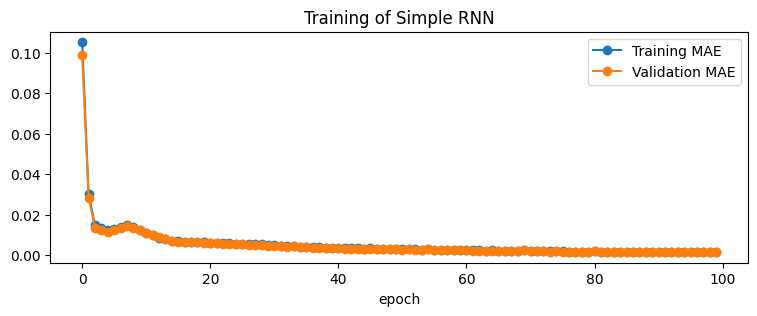

In [24]:
#plotting the training history of the SimpleRNN

numEpochs = len(historySrnn['epoch'])
plt.figure(figsize=(9,3))
plt.plot(range(numEpochs), historySrnn['mae'], marker='o', label='Training MAE')
plt.plot(range(numEpochs), historySrnn['valMae'], marker='o', label='Validation MAE')
plt.xlabel('epoch')
plt.title('Training of Simple RNN')
plt.legend();

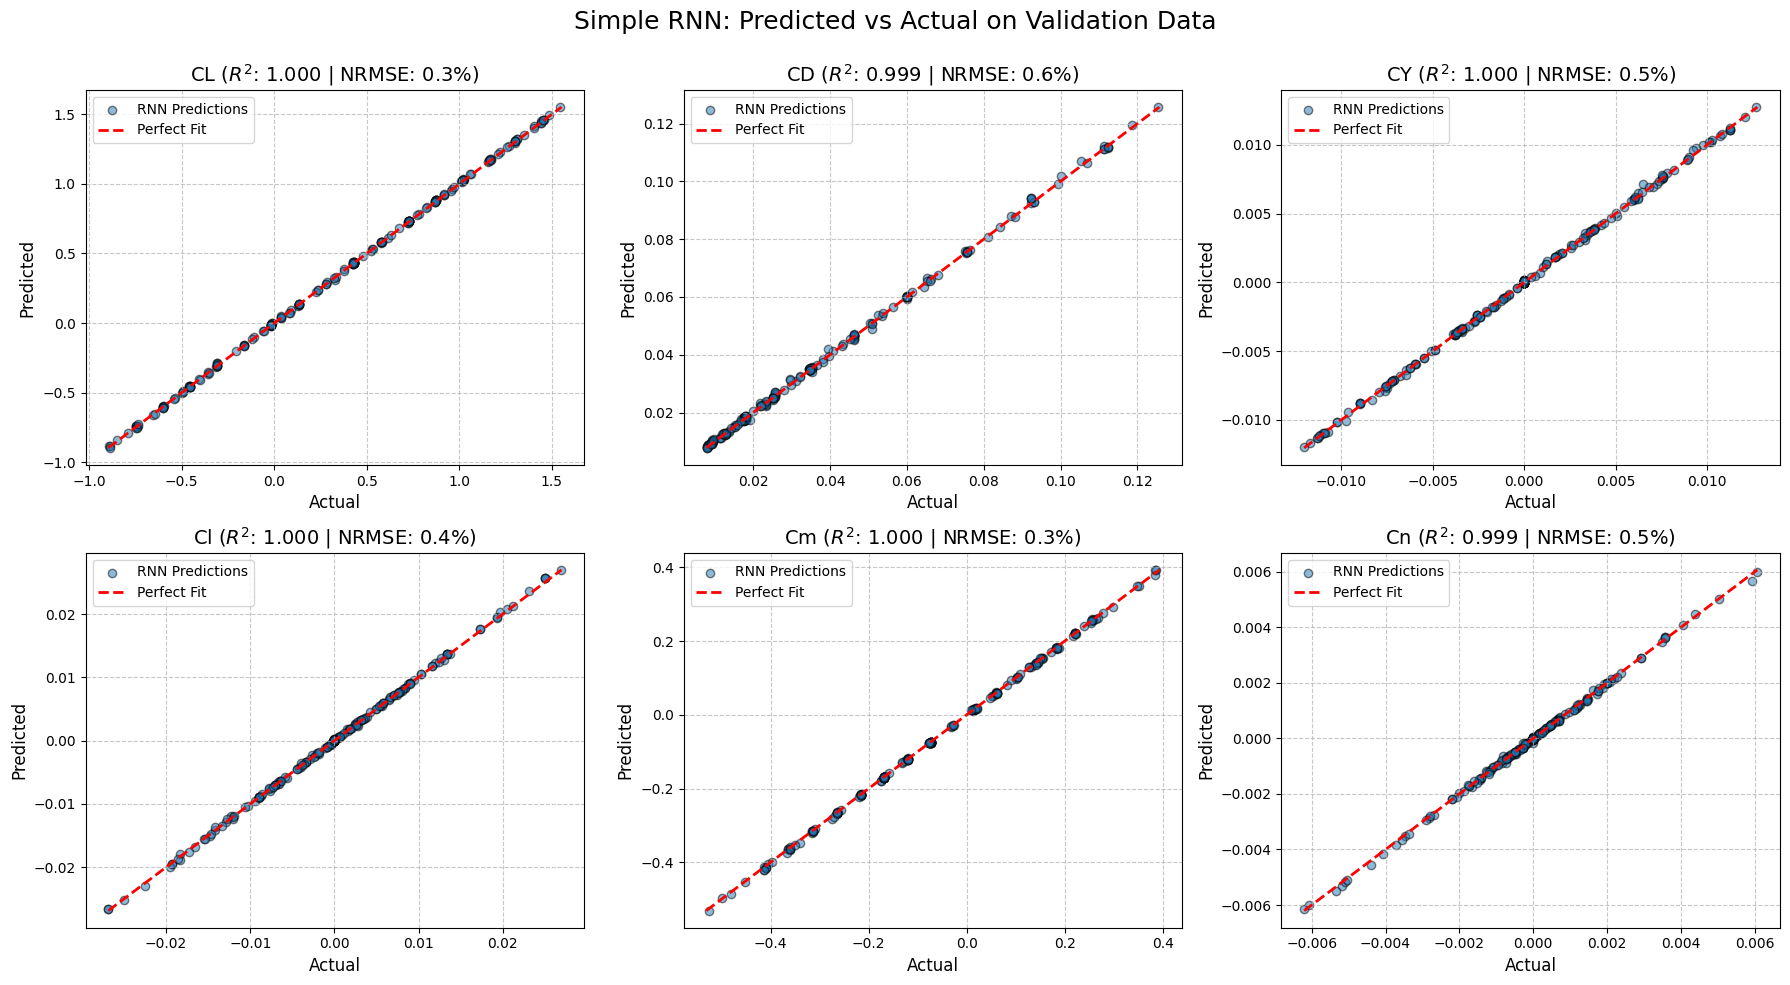

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

# Calculate raw MSE, then take the square root to get RMSE for all parameters
rnnValMse = mean_squared_error(yValidate, validatePred, multioutput='raw_values')
rnnValRmse = np.sqrt(rnnValMse)

# Calculate R-squared for all parameters
rnnValR2 = r2_score(yValidate, validatePred, multioutput='raw_values')

parameters = ["CL", "CD", "CY", "Cl", "Cm", "Cn"]

# Convert yValidate to a numpy array to handle column indexing safely
# (Assuming yValidate is a Pandas DataFrame from earlier)
yVal_array = np.array(yValidate)

# Set up the 2x3 plot grid
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Simple RNN: Predicted vs Actual on Validation Data', fontsize=18)

axes = axes.flatten()

for i, target in enumerate(parameters):
    ax = axes[i]
    
    # Extract actual and predicted values for this specific parameter
    actual = yVal_array[:, i]
    predicted = validatePred[:, i]
    
    # Calculate NRMSE (Normalized by the range of actual values)
    range_val = actual.max() - actual.min()
    nrmse = (rnnValRmse[i] / range_val) * 100 if range_val != 0 else 0
    
    # Actual vs predicted scatter plot
    ax.scatter(actual, predicted, alpha=0.5, edgecolor='k', label='RNN Predictions')
    
    # "Ideal" prediction line (y = x)
    min_val = min(actual.min(), predicted.min())
    max_val = max(actual.max(), predicted.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Fit')
    
    # Add R-squared and NRMSE percentage to the title
    ax.set_title(f"{target} ($R^2$: {rnnValR2[i]:.3f} | NRMSE: {nrmse:.1f}%)", fontsize=14)
    ax.set_xlabel('Actual', fontsize=12)
    ax.set_ylabel('Predicted', fontsize=12)
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.show()